<a href="https://colab.research.google.com/github/ssowmiya2206/flower-classification-multimodal-ai/blob/main/Copy_of_Untitled4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
import pathlib

# Download dataset automatically - no Kaggle needed!
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

print("Dataset ready!")
print(list(data_dir.glob('*')))

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset ready!
[PosixPath('/root/.keras/datasets/flower_photos/flower_photos')]


In [4]:
# Check flower categories
import pathlib

data_dir = pathlib.Path('/root/.keras/datasets/flower_photos/flower_photos')

print("Flower categories found:")
for item in data_dir.iterdir():
    if item.is_dir():
        count = len(list(item.glob('*.jpg')))
        print(f"  {item.name}: {count} images")

Flower categories found:
  sunflowers: 699 images
  roses: 641 images
  tulips: 799 images
  daisy: 633 images
  dandelion: 898 images


In [5]:
import tensorflow as tf

# Settings
IMG_SIZE = 180
BATCH_SIZE = 32

# Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [6]:
# Build and train the model
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(train_ds, validation_data=val_ds, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.4220 - loss: 1.3084 - val_accuracy: 0.5272 - val_loss: 1.0896
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5899 - loss: 1.0059 - val_accuracy: 0.6144 - val_loss: 0.9859
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6686 - loss: 0.8502 - val_accuracy: 0.6499 - val_loss: 0.9075
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7357 - loss: 0.6936 - val_accuracy: 0.6485 - val_loss: 0.8901
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8151 - loss: 0.4837 - val_accuracy: 0.6431 - val_loss: 1.0126
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8995 - loss: 0.2940 - val_accuracy: 0.6526 - val_loss: 1.0599
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9418 - loss: 0.1724 - val_accuracy: 0.6798 - val_loss: 1.2535
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9707 - loss: 0.0817 - val_accuracy: 0.6662 -

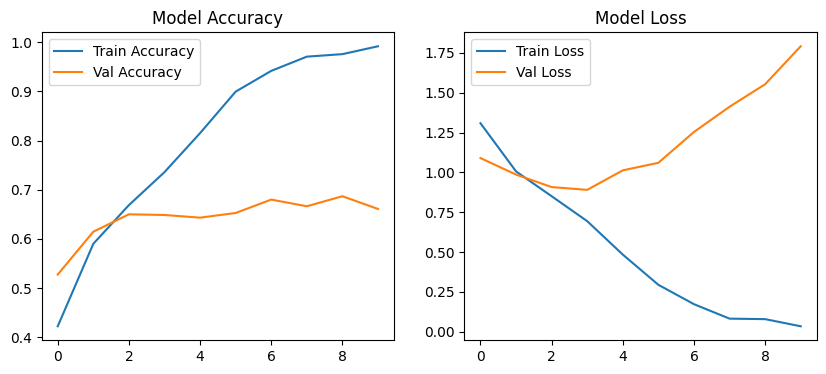

Model saved!


In [7]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

# Save model
model.save('flower_classifier.h5')
print("Model saved!")

In [8]:
# Fixed model with Dropout to prevent overfitting
model2 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes)
])

model2.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history2 = model2.fit(train_ds, validation_data=val_ds, epochs=15)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.3171 - loss: 1.5796 - val_accuracy: 0.5395 - val_loss: 1.1668
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5228 - loss: 1.1370 - val_accuracy: 0.5981 - val_loss: 1.0480
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5739 - loss: 1.0529 - val_accuracy: 0.6131 - val_loss: 0.9723
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6526 - loss: 0.8928 - val_accuracy: 0.6308 - val_loss: 0.9095
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.6969 - loss: 0.7940 - val_accuracy: 0.6403 - val_loss: 0.8706
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7466 - loss: 0.6545 - val_accuracy: 0.6921 - val_loss: 0.8287
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8045 - loss: 0.5227 - val_accuracy: 0.6785 - val_loss: 0.8714
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8576 - loss: 0.3943 - val_accuracy: 0.6907 - 

In [9]:
# Transfer Learning with MobileNetV2 - much better accuracy!
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model3 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./127.5, offset=-1, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes)
])

model3.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history3 = model3.fit(train_ds, validation_data=val_ds, epochs=10)

/tmp/ipykernel_3880/182395452.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 51s 348ms/step - accuracy: 0.6693 - loss: 0.8833 - val_accuracy: 0.8243 - val_loss: 0.4697
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8433 - loss: 0.4320 - val_accuracy: 0.8665 - val_loss: 0.3840
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8777 - loss: 0.3418 - val_accuracy: 0.8747 - val_loss: 0.3768
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8931 - loss: 0.2992 - val_accuracy: 0.8856 - val_loss: 0.3437
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9053 - loss: 0.2746 - val_accuracy: 0.8924 - val_loss: 0.3223
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9131 - loss: 0.2403 - val_accuracy: 0.8842 - val_loss: 0.3402
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9210 - loss: 0.2284 - val_accuracy: 0.8842 - val_loss: 0.3187
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accurac

Best model saved!
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


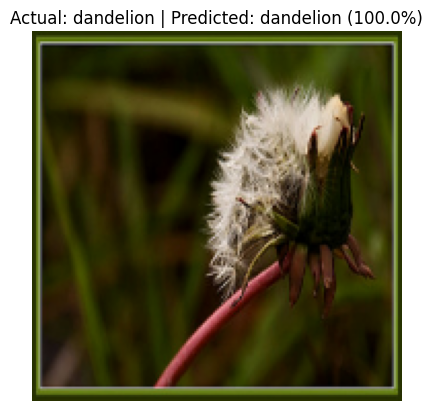

In [10]:
# Save best model
model3.save('flower_classifier_v2.h5')
print("Best model saved!")

# Test prediction on a sample image
import numpy as np

# Take one image from validation set
for images, labels in val_ds.take(1):
    img = images[0]
    actual = class_names[labels[0]]

    pred = model3.predict(tf.expand_dims(img, 0))
    predicted = class_names[np.argmax(pred)]
    confidence = round(float(tf.nn.softmax(pred)[0][np.argmax(pred)]) * 100, 2)

    plt.imshow(img.numpy().astype('uint8'))
    plt.title(f"Actual: {actual} | Predicted: {predicted} ({confidence}%)")
    plt.axis('off')
    plt.show()

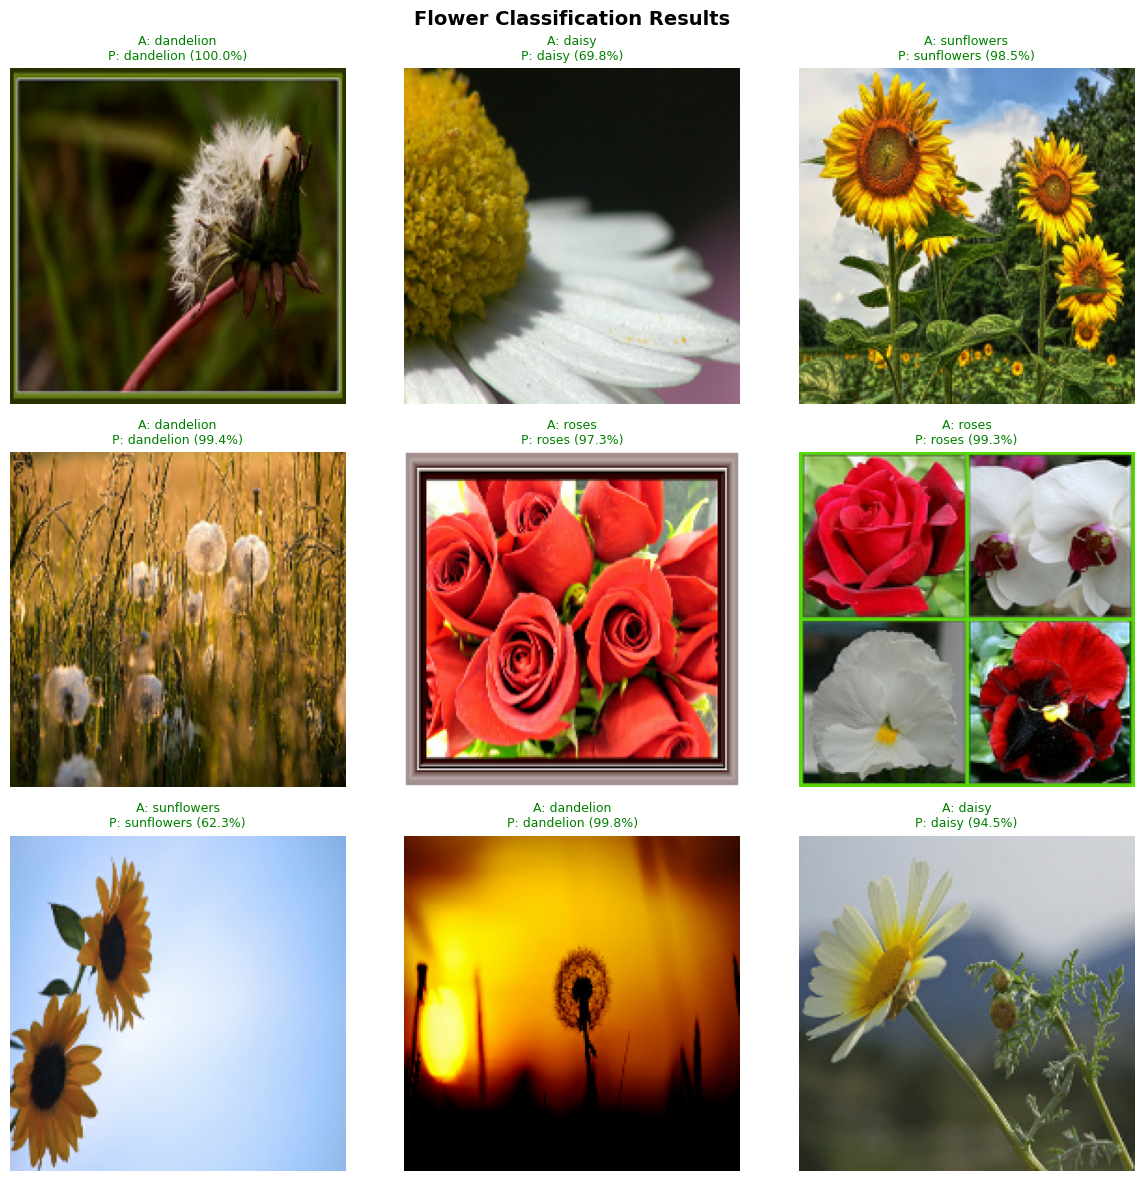

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 12))

i = 0
for images, labels in val_ds.take(3):
    for j in range(3):
        ax = plt.subplot(3, 3, i + 1)
        img = images[j]
        actual = class_names[labels[j]]

        pred = model3.predict(tf.expand_dims(img, 0), verbose=0)
        predicted = class_names[np.argmax(pred)]
        confidence = round(float(tf.nn.softmax(pred)[0][np.argmax(pred)]) * 100, 1)

        plt.imshow(img.numpy().astype('uint8'))

        color = 'green' if actual == predicted else 'red'
        plt.title("A: " + actual + "\nP: " + predicted + " (" + str(confidence) + "%)", color=color, fontsize=9)
        plt.axis('off')
        i += 1

plt.suptitle('Flower Classification Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Saving sunflower.jpg to sunflower.jpg


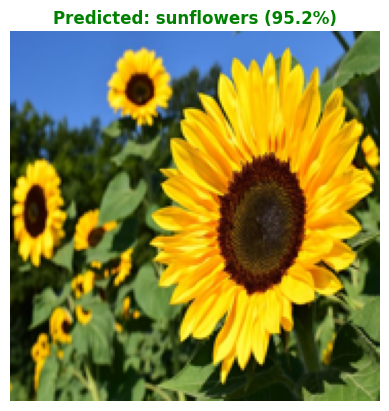

In [12]:
from google.colab import files
from PIL import Image
import numpy as np
import tensorflow as tf

# Upload your image
uploaded = files.upload()

# Get the filename
img_path = list(uploaded.keys())[0]

# Load and display image
img = Image.open(img_path).resize((180, 180))
plt.imshow(img)
plt.axis('off')

# Predict
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

pred = model3.predict(img_array, verbose=0)
predicted = class_names[np.argmax(pred)]
confidence = round(float(tf.nn.softmax(pred)[0][np.argmax(pred)]) * 100, 1)

plt.title("Predicted: " + predicted + " (" + str(confidence) + "%)",
          fontsize=12, fontweight='bold', color='green')
plt.show()

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import numpy as np

# Flower review dataset
reviews = [
    "This flower is absolutely beautiful and gorgeous",
    "Amazing and stunning flower love it",
    "Wonderful lovely flower very pretty",
    "Beautiful bloom gorgeous petals",
    "Lovely flower pretty and vibrant",
    "This flower is ugly and boring",
    "Terrible looking plant very bad",
    "Awful flower dull and lifeless",
    "Very bad ugly wilted flower",
    "Horrible plant not good at all"
]

labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]  # 1=Positive, 0=Negative

# Train sentiment model
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(reviews)

sentiment_model = LogisticRegression()
sentiment_model.fit(X, labels)

print("Sentiment model trained!")

# Test it
test_reviews = [
    "This sunflower is so beautiful and bright!",
    "The flower looks dead and ugly"
]

for review in test_reviews:
    vec = vectorizer.transform([review])
    pred = sentiment_model.predict(vec)[0]
    prob = sentiment_model.predict_proba(vec)[0][pred]
    sentiment = "Positive 😊" if pred == 1 else "Negative 😞"
    print(f"\nReview: {review}")
    print(f"Sentiment: {sentiment} ({round(prob*100, 1)}%)")

Sentiment model trained!

Review: This sunflower is so beautiful and bright!
Sentiment: Positive 😊 (53.9%)

Review: The flower looks dead and ugly
Sentiment: Negative 😞 (55.5%)


🌸 MULTIMODAL AI RESULT
🌼 Flower Detected : sunflowers (95.2%)
💬 Review Sentiment: Positive 😊 (53.9%)
⭐ Recommendation  : Highly Recommended!


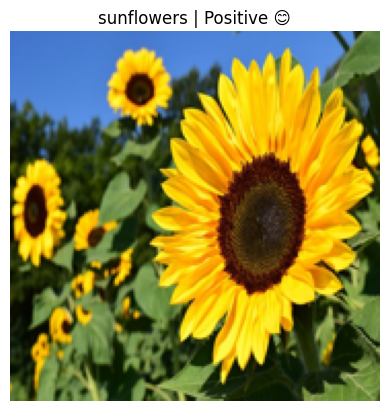

In [14]:
# FINAL MULTIMODAL AI - Combines Image + Text
def multimodal_predict(img_path, review_text):

    # --- IMAGE PREDICTION ---
    img = Image.open(img_path).resize((180, 180))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    pred = model3.predict(img_array, verbose=0)
    flower = class_names[np.argmax(pred)]
    img_confidence = round(float(tf.nn.softmax(pred)[0][np.argmax(pred)]) * 100, 1)

    # --- SENTIMENT PREDICTION ---
    vec = vectorizer.transform([review_text])
    sentiment_pred = sentiment_model.predict(vec)[0]
    sentiment_prob = sentiment_model.predict_proba(vec)[0][sentiment_pred]
    sentiment = "Positive 😊" if sentiment_pred == 1 else "Negative 😞"
    sentiment_conf = round(sentiment_prob * 100, 1)

    # --- COMBINED OUTPUT ---
    print("=" * 40)
    print("🌸 MULTIMODAL AI RESULT")
    print("=" * 40)
    print(f"🌼 Flower Detected : {flower} ({img_confidence}%)")
    print(f"💬 Review Sentiment: {sentiment} ({sentiment_conf}%)")

    if sentiment_pred == 1:
        print(f"⭐ Recommendation  : Highly Recommended!")
    else:
        print(f"⚠️  Recommendation  : Not Recommended")
    print("=" * 40)

    plt.imshow(img)
    plt.title(flower + " | " + sentiment)
    plt.axis('off')
    plt.show()

# Test it with your sunflower image
multimodal_predict("sunflower.jpg", "This sunflower is so beautiful and bright!")

In [15]:
!pip install gradio transformers -q

In [16]:
from transformers import pipeline
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# Load HuggingFace sentiment model
sentiment_analyzer = pipeline("sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english")

def predict(image, review):
    # Image prediction
    img = image.resize((180, 180))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    pred = model3.predict(img_array, verbose=0)
    flower = class_names[np.argmax(pred)]
    confidence = round(float(tf.nn.softmax(pred)[0][np.argmax(pred)]) * 100, 1)

    # HuggingFace sentiment
    result = sentiment_analyzer(review)[0]
    sentiment = "Positive 😊" if result['label'] == 'POSITIVE' else "Negative 😞"
    sent_conf = round(result['score'] * 100, 1)

    output = f"""
🌸 Flower Detected  : {flower} ({confidence}%)
💬 Sentiment        : {sentiment} ({sent_conf}%)
⭐ Recommendation   : {"Highly Recommended!" if result['label'] == 'POSITIVE' else "Not Recommended"}
"""
    return output

app = gr.Interface(
    fn=predict,
    inputs=[gr.Image(type="pil"), gr.Textbox(label="Write a review")],
    outputs=gr.Textbox(label="AI Result"),
    title="🌸 Multimodal Flower AI",
    description="Upload a flower image and write a review!"
)

app.launch(share=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cb8ab3654a16010e91.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
